# Structured Jet — Yonetoku MCMC Run

This notebook is identical in structure to `structured_jet_run.ipynb` but promotes the
**Yonetoku slope** $\gamma_y$ to a free parameter.

## Physical model

Instead of drawing $\hat{E}_p$ from a log-normal with a fixed mean $\mu_E$, the
peak energy of each event is conditioned on its luminosity:

$$
\log_{10}\hat{E}_{p,i} = \mu_E + \gamma_y \cdot \log_{10}L_i + \sigma_E \cdot \mathcal{N}(0,1)
$$

where $L_i$ is the dimensionless Schechter draw (so $\mu_E$ is still the typical
$\log_{10}E_p$ at the characteristic luminosity $L=1$). Setting $\gamma_y = 0$
recovers the baseline model exactly. The canonical Yonetoku (2004) value is
$\gamma_y \approx 0.5$.

## Parameter vector (8-dimensional)

| # | Symbol | Description |
|---|--------|-------------|
| 0 | $k$ | Schechter / gen-gamma power-law index |
| 1 | $\log_{10}L_0$ | Luminosity scale (× 10⁴⁹ erg) |
| 2 | $\mu_E$ | Mean $\log_{10}(\hat{E}_p/{\rm keV})$ at $L=1$ |
| 3 | $\sigma_E$ | Intrinsic $E_p$ scatter (dex) |
| 4 | $\mu_\tau$ | Mean $\log_{10}(t_{\rm peak}/{\rm s})$ |
| 5 | $\sigma_\tau$ | Intrinsic duration scatter (dex) |
| 6 | $f_j$ | Jet fraction (Poisson rate term) |
| 7 | $\gamma_y$ | Yonetoku slope |

## 1. Setup

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import numpy as np
import matplotlib.pyplot as plt
import emcee
from math import inf
from pathlib import Path

# Add repo root to path when running from Paper_Notebooks/
repo_root = Path.cwd().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

# ── Yonetoku-extended pipeline ───────────────────────────────────────────────
from src.structured_jet import (
    initialize_simulation,
    log_likelihood_fj_yonetoku,
    make_observations_yonetoku,
    generate_grb_population_yonetoku,
    DEFAULT_LIMITS,
    GBM_EFF,
    L_MIN_FACTOR,
    N_YEARS_DEFAULT,
    create_log_prior_yonetoku,
    initialize_walkers_yonetoku,
    DEFAULT_PRIOR_BOUNDS_YONETOKU,
)
from src.init import create_run_dir
from src.multiprocessing_MC import run_mcmc_parallel

plt.style.use('../configurations/style.mplstyle')

print(f"GBM_EFF          = {GBM_EFF}")
print(f"L_MIN_FACTOR     = {L_MIN_FACTOR}")
print(f"N_YEARS_DEFAULT  = {N_YEARS_DEFAULT} yr")

GBM_EFF          = 0.6
L_MIN_FACTOR     = 0.0001
N_YEARS_DEFAULT  = 16.0 yr


## 2. Output directory

In [2]:
datafiles  = Path("../datafiles")
output_dir = create_run_dir(
    "structured_jet/fj_run_yonetoku",
    use_timestamp=True,
    output_files_default="../Output_files",
)
print(f"Output directory: {output_dir}")

Creating new directory : ../Output_files/structured_jet/fj_run_yonetoku__2026-02-27_13-18-19
Output directory: ../Output_files/structured_jet/fj_run_yonetoku__2026-02-27_13-18-19


## 3. Model parameters

Jet structure fixed at `s = 4.0`, `θ_c = 3.4°` (GW170817 constraints).  
Note that `L_mu_E` is now the **conditional zero-point**: the mean of
$\log_{10}\hat{E}_p$ when $L_i = 1$ (the characteristic Schechter luminosity).

In [3]:
params = {
    "alpha"       : -0.67,
    "beta_s"      : -2.59,
    "n"           : 2,
    "theta_c"     : 3.4,
    "theta_v_max" : 10,
    "z_model"     : "fiducial_Hrad_A1.0",
}

print("Model parameters:")
for k, v in params.items():
    print(f"  {k:15s} = {v}")

Model parameters:
  alpha           = -0.67
  beta_s          = -2.59
  n               = 2
  theta_c         = 3.4
  theta_v_max     = 10
  z_model         = fiducial_Hrad_A1.0


## 4. Initialise simulation

In [4]:
sim_params, interps, data_dict = initialize_simulation(datafiles, params)

n_years  = sim_params.triggered_years
n_bns_yr = len(sim_params.z_arr)

print(f"\nCatalogue duration    : {n_years:.1f} yr")
print(f"Observed yearly rate  : {sim_params.yearly_rate:.2f} sGRBs/yr")
print(f"BNS per year (z_arr)  : {n_bns_yr:,}")
print(f"Catalogue sGRBs       : {sim_params.yearly_rate * n_years:.0f}")
print()
print("Detection limits:")
for k, v in DEFAULT_LIMITS.items():
    print(f"  {k:15s} = {v}")

Using redshift model: samples_fiducial_Hrad_A1.0_BNSs_0.dat with 359079 BNSs.
Generating temporal interpolators... (this may take a moment)
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year

Catalogue duration    : 17.5 yr
Observed yearly rate  : 18.58 sGRBs/yr
BNS per year (z_arr)  : 359,079
Catalogue sGRBs       : 325

Detection limits:
  F_LIM           = 4
  T90_LIM         = 2
  EP_LIM_UPPER    = 10000
  EP_LIM_LOWER    = 50


## 5. Prior and walkers

`gamma_y` prior is flat on $[-0.5,\, 1.5]$ — wide enough to include the canonical
Yonetoku value (0.5) and negative slopes (anti-correlation).  
Walkers are initialised around $\gamma_y \in [0.2, 0.8]$.

In [5]:
prior_bounds = dict(DEFAULT_PRIOR_BOUNDS_YONETOKU)
prior_bounds["f_j"] = (0, 20)   # free fj — same as CvM run
print("Prior bounds (8 parameters):")
for name, (lo, hi) in prior_bounds.items():
    print(f"  {name:12s}: [{lo}, {hi}]")

log_prior = create_log_prior_yonetoku(prior_bounds)

Prior bounds (8 parameters):
  k           : [1.5, 6]
  L_L0        : [-3, 2]
  L_mu_E      : [2.5, 5]
  sigma_E     : [0, 1]
  L_mu_tau    : [-2, 2.5]
  sigma_tau   : [0, 1.8]
  f_j         : [0, 20]
  gamma_y     : [-0.5, 1.5]


In [6]:
# ── log-probability = log-prior + log_likelihood_fj_yonetoku ────────────────
def log_probability(thetas):
    lp = log_prior(thetas)
    if not np.isfinite(lp):
        return -inf, None, None, None, None, None
    ll, yr_rate, lE, lT, lP, lF = log_likelihood_fj_yonetoku(
        thetas,
        sim_params,
        interps,
        limits=DEFAULT_LIMITS,
    )
    return lp + ll, yr_rate, lE, lT, lP, lF

# ── sanity check ─────────────────────────────────────────────────────────────
geo_eff        = 1 - np.cos(sim_params.theta_v_max)
n_events_check = int(len(sim_params.z_arr) * n_years * geo_eff)
print(f"Geometric MC draw size : {n_events_check:,}  events")
print(f"  = {len(sim_params.z_arr):,} BNS/yr  ×  {n_years:.1f} yr  ×  {geo_eff:.4f} (geo_eff)")

#   [k, L_L0, L_mu_E, sigma_E, L_mu_tau, sigma_tau, fj, gamma_y]
thetas_test = [2.5, -0.5, 3.2, 0.35, -0.3, 0.7, 0.15, 0.5]
result = log_probability(thetas_test)
print(f"\nlog_prob at test point : {result[0]:.3f}")
print(f"simulated yearly rate  : {result[1]}")

Geometric MC draw size : 95,440  events
  = 359,079 BNS/yr  ×  17.5 yr  ×  0.0152 (geo_eff)

log_prob at test point : -158.887
simulated yearly rate  : 7.243067533712936


## 6. Walkers

8-dimensional walker initialisation.  `gamma_y` starts uniform on [0.2, 0.8].

In [7]:
N_WALKERS = 32
N_STEPS   = 2000
N_DIM     = 8    # [k, L_L0, L_mu_E, sigma_E, L_mu_tau, sigma_tau, fj, gamma_y]

initial_pos = initialize_walkers_yonetoku(N_WALKERS, seed=42, max_fj=0.8)
print(f"Walkers       : {initial_pos.shape}")
print(f"fj range      : [{initial_pos[:, -2].min():.3f}, {initial_pos[:, -2].max():.3f}]")
print(f"gamma_y range : [{initial_pos[:, -1].min():.3f}, {initial_pos[:, -1].max():.3f}]")

Walkers       : (32, 8)
fj range      : [0.060, 0.779]
gamma_y range : [0.211, 0.780]


## 7. MCMC run

Blobs: `(yearly_rate, logL_epeak, logL_t90, logL_pflux, logL_fluence)` — same as the CvM baseline.

In [8]:
backend_file = output_dir / "emcee_yonetoku.h5"

blobs_dtype = [
    ("yearly_rate",  float),
    ("logL_epeak",   float),
    ("logL_t90",     float),
    ("logL_pflux",   float),
    ("logL_fluence", float),
]

backend = emcee.backends.HDFBackend(str(backend_file))

run_mcmc_parallel(
    log_probability = log_probability,
    initial_pos     = initial_pos,
    max_n           = N_STEPS,
    backend         = backend,
    blobs_dtype     = blobs_dtype,
    progress        = True,
)

print(f"\nChain saved to {backend_file}")

Running MCMC with 11 workers (2000 steps)...


100%|██████████| 100/100 [00:20<00:00,  4.98it/s]


✓ MCMC complete. Mean acceptance fraction: 0.060

Chain saved to ../Output_files/structured_jet/fj_run_yonetoku__2026-02-27_13-18-19/emcee_yonetoku.h5


## 8. Chain diagnostics

In [9]:
reader = emcee.backends.HDFBackend(str(backend_file), read_only=True)
print(f"Chain shape : {reader.get_chain().shape}   (steps, walkers, ndim)")
print(f"Acceptance  : {reader.accepted.mean() / reader.iteration:.3f} (mean fraction)")

param_names = ["k", "L_L0", "L_mu_E", "sigma_E", "L_mu_tau", "sigma_tau", "fj", "gamma_y"]

try:
    tau = reader.get_autocorr_time(tol=0)
    print(f"\nAutocorrelation times:")
    for n, t in zip(param_names, tau):
        print(f"  {n:12s}: {t:.1f} steps")
    burn_in = int(3 * np.max(tau))
    thin    = max(1, int(0.5 * np.min(tau)))
    print(f"\nSuggested burn-in : {burn_in} steps")
    print(f"Suggested thinning: every {thin} steps")
except emcee.autocorr.AutocorrError as e:
    print(f"Autocorr not converged yet: {e}")
    burn_in = N_STEPS // 4
    thin    = 1

Chain shape : (2000, 32, 8)   (steps, walkers, ndim)
Acceptance  : 0.060 (mean fraction)

Autocorrelation times:
  k           : 190.2 steps
  L_L0        : 173.6 steps
  L_mu_E      : 186.3 steps
  sigma_E     : 158.2 steps
  L_mu_tau    : 176.1 steps
  sigma_tau   : 172.3 steps
  fj          : 223.0 steps
  gamma_y     : 178.5 steps

Suggested burn-in : 668 steps
Suggested thinning: every 79 steps


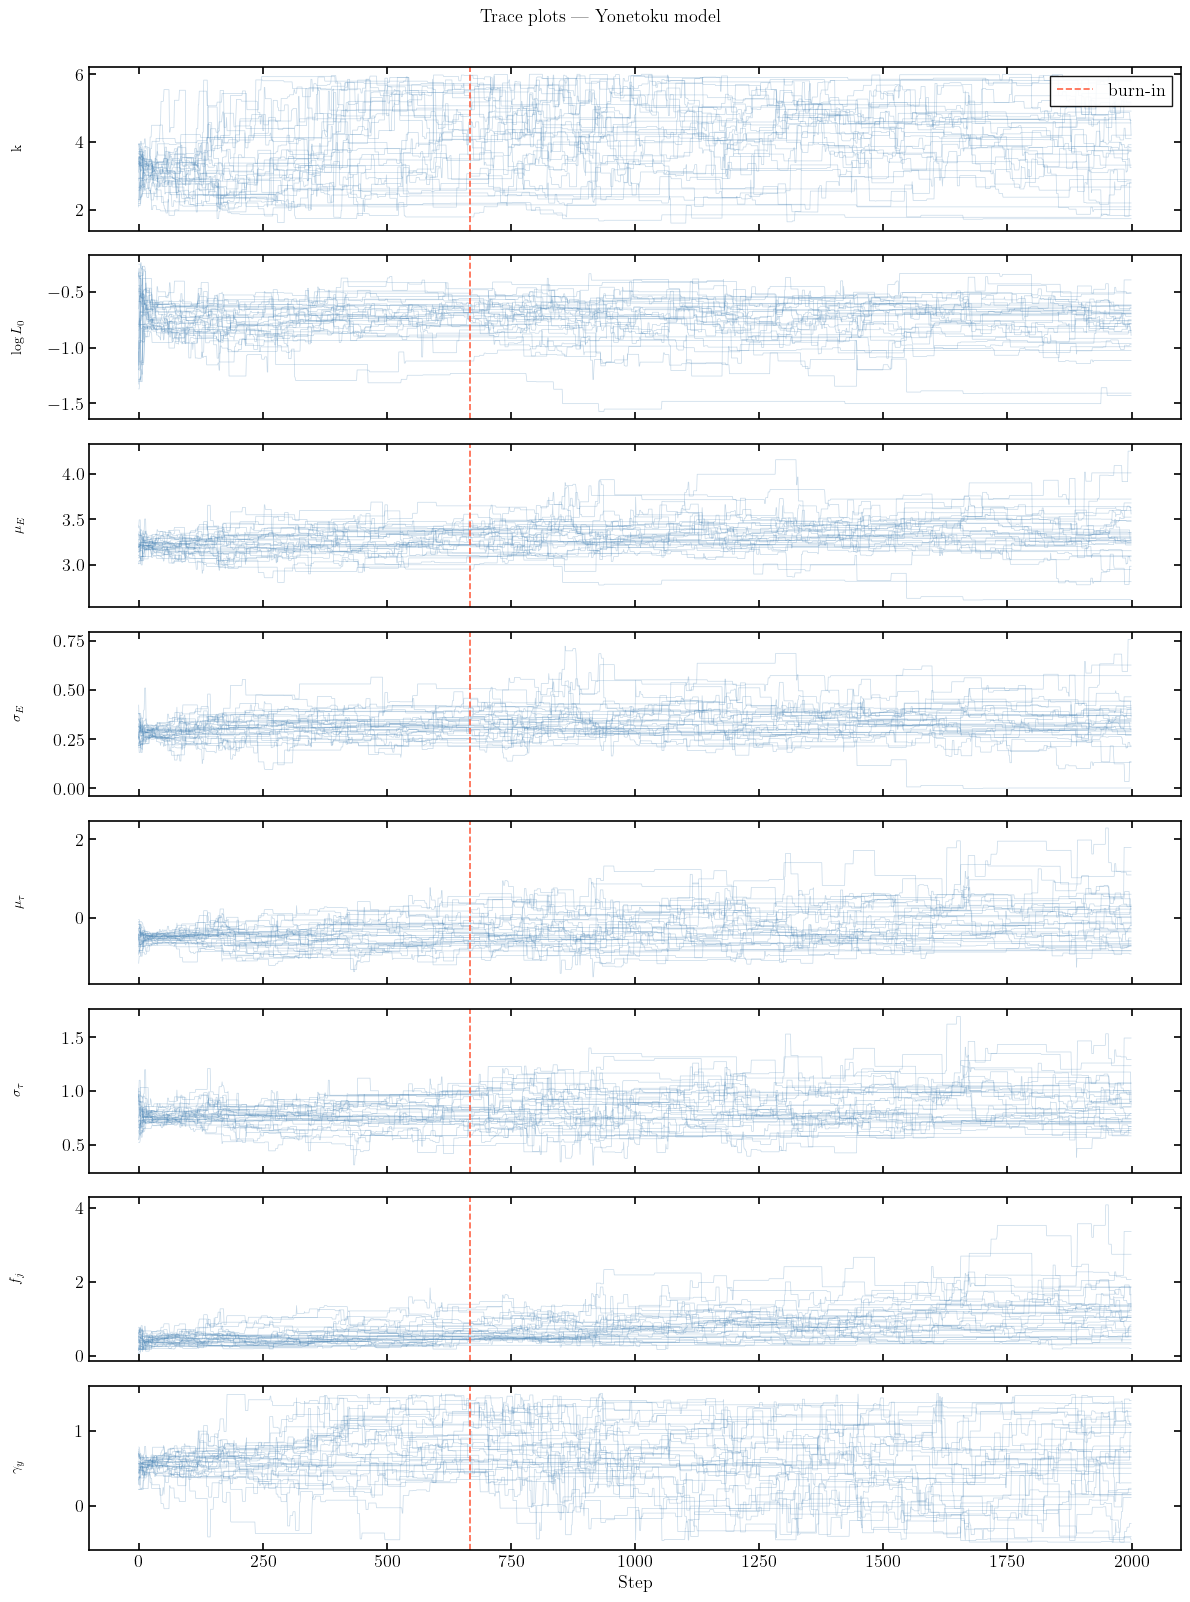

In [10]:
param_labels_trace = [
    "k", r"$\log L_0$", r"$\mu_E$", r"$\sigma_E$",
    r"$\mu_\tau$", r"$\sigma_\tau$", r"$f_j$", r"$\gamma_y$",
]

chain = reader.get_chain()   # (steps, walkers, ndim)

fig, axes = plt.subplots(N_DIM, 1, figsize=(12, 16), sharex=True)
for i, (ax, name) in enumerate(zip(axes, param_labels_trace)):
    ax.plot(chain[:, :, i], alpha=0.3, lw=0.5, color="steelblue")
    ax.axvline(burn_in, color="tomato", ls="--", lw=1.2, label="burn-in" if i == 0 else None)
    ax.set_ylabel(name, fontsize=10)
    ax.yaxis.set_label_coords(-0.06, 0.5)
axes[-1].set_xlabel("Step")
axes[0].legend(loc="upper right")
fig.suptitle("Trace plots — Yonetoku model", fontsize=13, y=1.001)
fig.tight_layout()
fig.savefig(output_dir / "trace_plots.pdf", bbox_inches="tight")
plt.show()

## 9. Posterior corner plot

Flat samples shape: (512, 8)


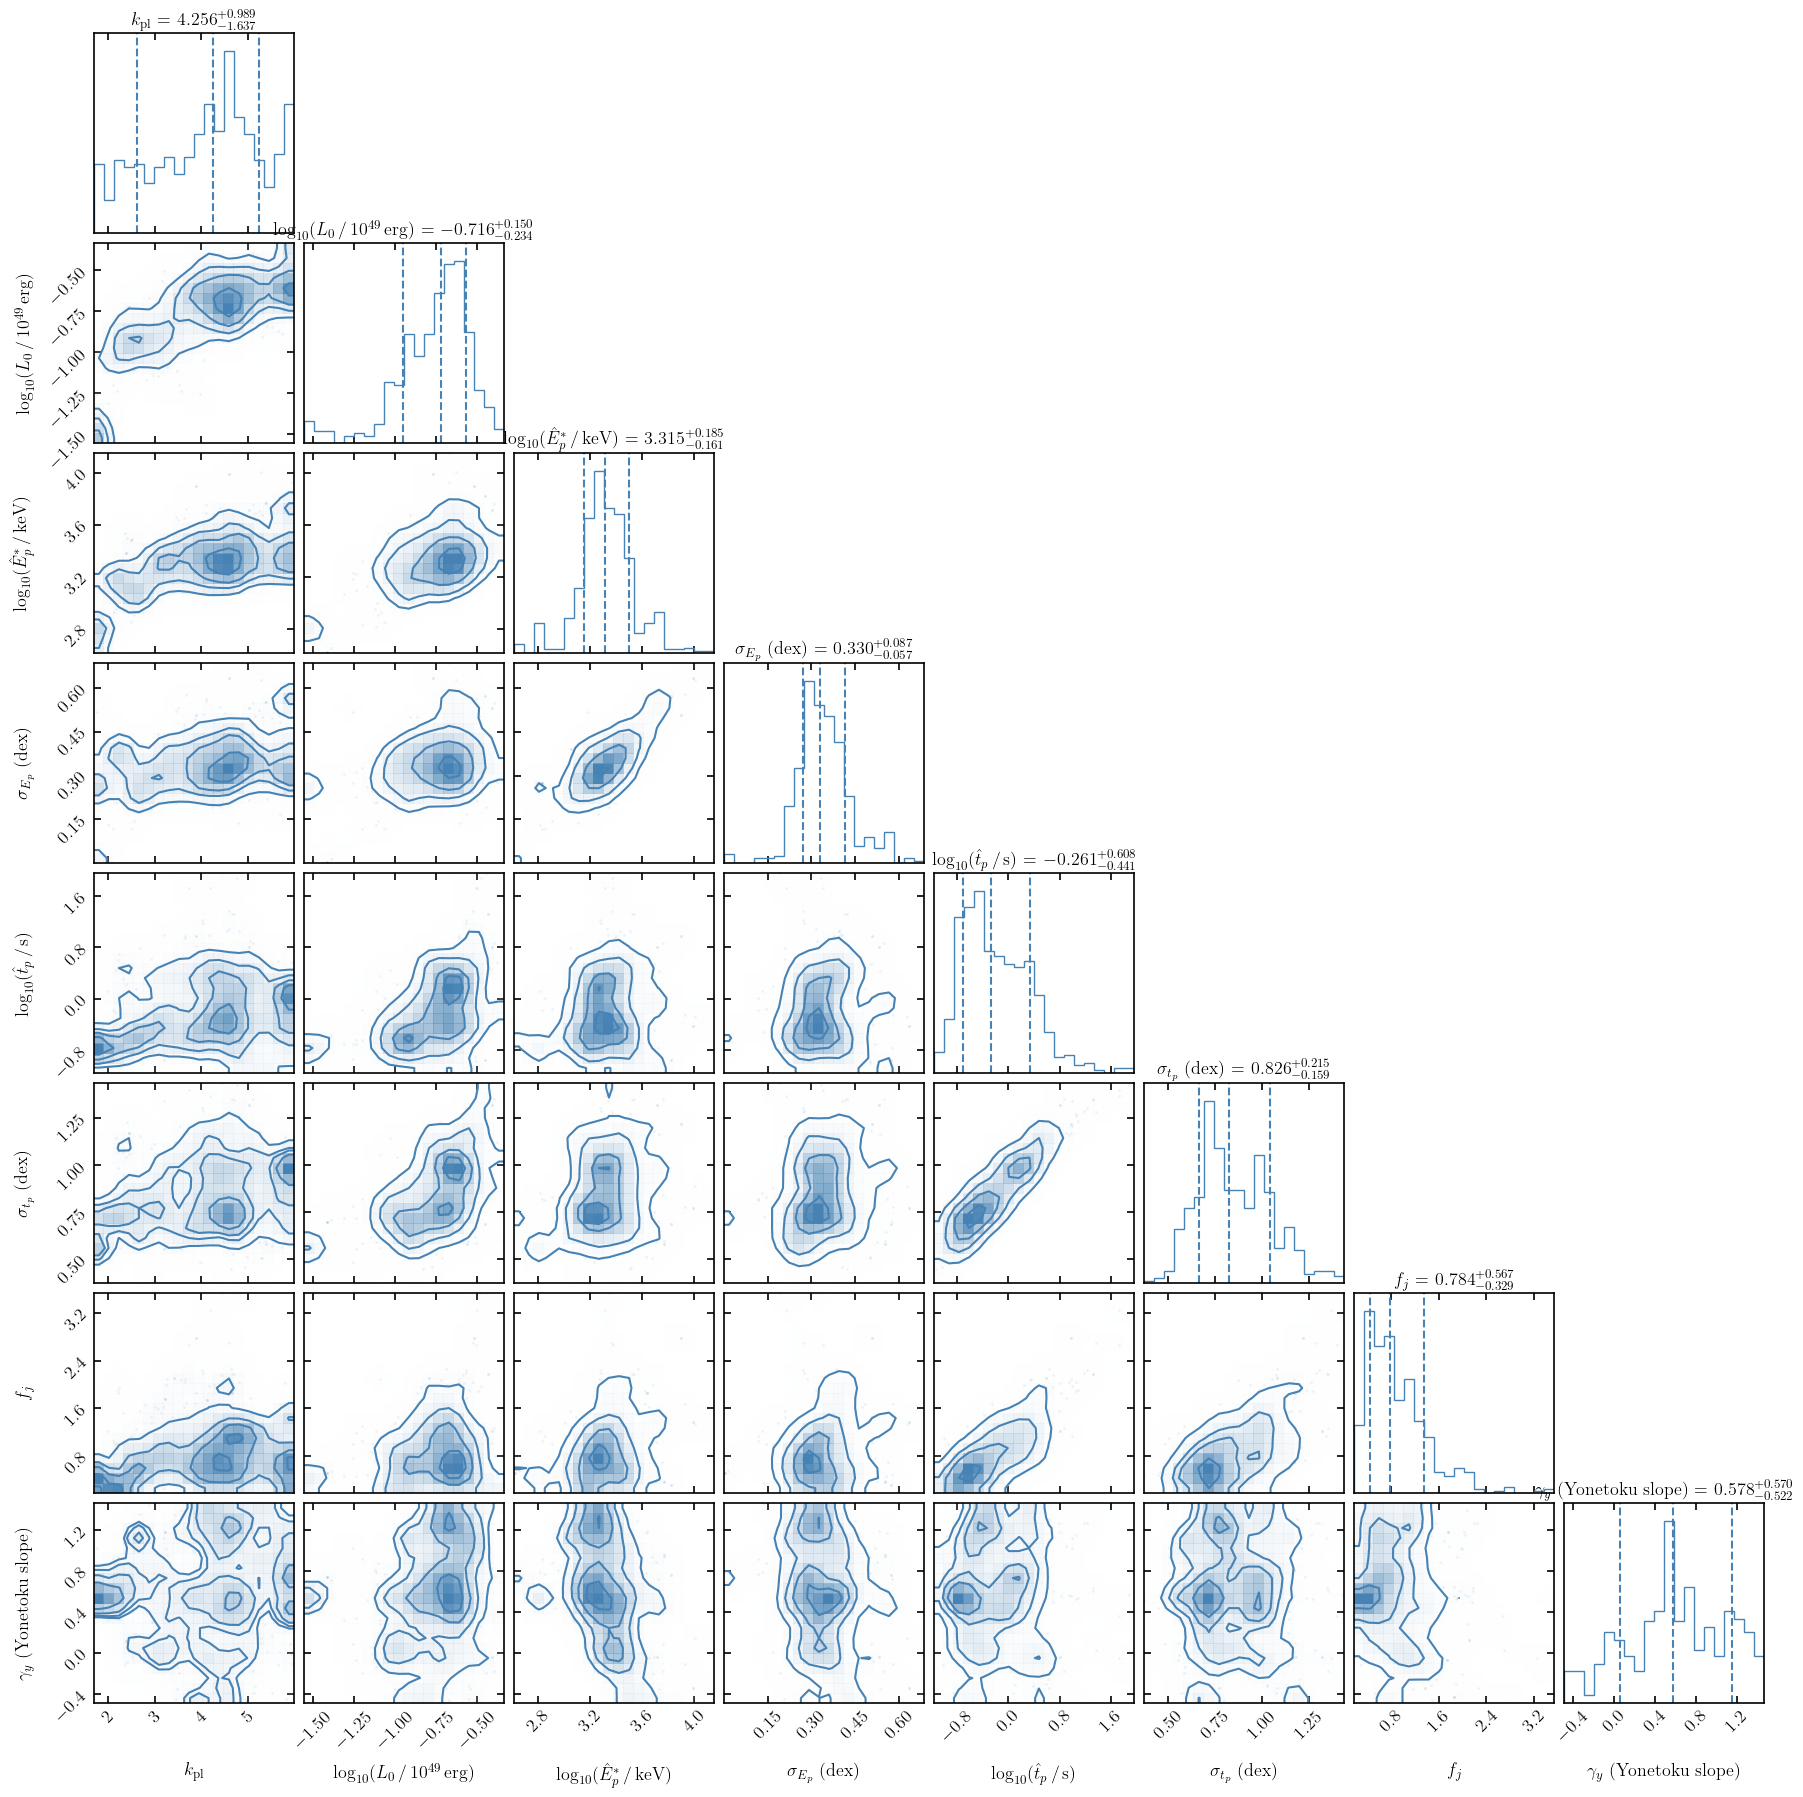


Posterior medians and 1-σ intervals:
  $k_{\rm pl}$                                 : +4.256  +0.989  -1.637
  $\log_{10}(L_0\,/\,10^{49}\,{\rm erg})$      : -0.716  +0.150  -0.234
  $\log_{10}(\hat{E}_p^*\,/\,{\rm keV})$       : +3.315  +0.185  -0.161
  $\sigma_{E_p}$  (dex)                        : +0.330  +0.087  -0.057
  $\log_{10}(\hat{t}_p\,/\,{\rm s})$           : -0.261  +0.608  -0.441
  $\sigma_{t_p}$  (dex)                        : +0.826  +0.215  -0.159
  $f_j$                                        : +0.784  +0.567  -0.329
  $\gamma_y$  (Yonetoku slope)                 : +0.578  +0.570  -0.522


In [11]:
try:
    import corner
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "corner", "-q"])
    import corner

flat_samples = reader.get_chain(discard=burn_in, thin=thin, flat=True)
print(f"Flat samples shape: {flat_samples.shape}")

param_labels = [
    r"$k_{\rm pl}$",
    r"$\log_{10}(L_0\,/\,10^{49}\,{\rm erg})$",
    r"$\log_{10}(\hat{E}_p^*\,/\,{\rm keV})$",
    r"$\sigma_{E_p}$  (dex)",
    r"$\log_{10}(\hat{t}_p\,/\,{\rm s})$",
    r"$\sigma_{t_p}$  (dex)",
    r"$f_j$",
    r"$\gamma_y$  (Yonetoku slope)",
]

fig = corner.corner(
    flat_samples,
    labels=param_labels,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_fmt=".3f",
    smooth=1.0,
    color="steelblue",
)
fig.savefig(output_dir / "corner_yonetoku.pdf", bbox_inches="tight")
plt.show()

print("\nPosterior medians and 1-σ intervals:")
for label, p in zip(param_labels, flat_samples.T):
    lo, med, hi = np.percentile(p, [16, 50, 84])
    print(f"  {label:45s}: {med:+.3f}  +{hi-med:.3f}  -{med-lo:.3f}")

## 10. Posterior predictive check (PPC)

In [12]:
N_PPC = 200

rng_ppc    = np.random.default_rng(0)
idx_ppc    = rng_ppc.integers(0, len(flat_samples), N_PPC)
ppc_samples = flat_samples[idx_ppc]

ppc_results = []
for theta in ppc_samples:
    pop = generate_grb_population_yonetoku(
        theta, sim_params, interps,
        limits=DEFAULT_LIMITS,
        n_events=n_events_check,
    )
    if pop is not None:
        ppc_results.append(pop)

print(f"MC draw size per PPC realisation : {n_events_check:,}")
print(f"PPC realisations with detections : {len(ppc_results)} / {N_PPC}")

MC draw size per PPC realisation : 95,440
PPC realisations with detections : 200 / 200


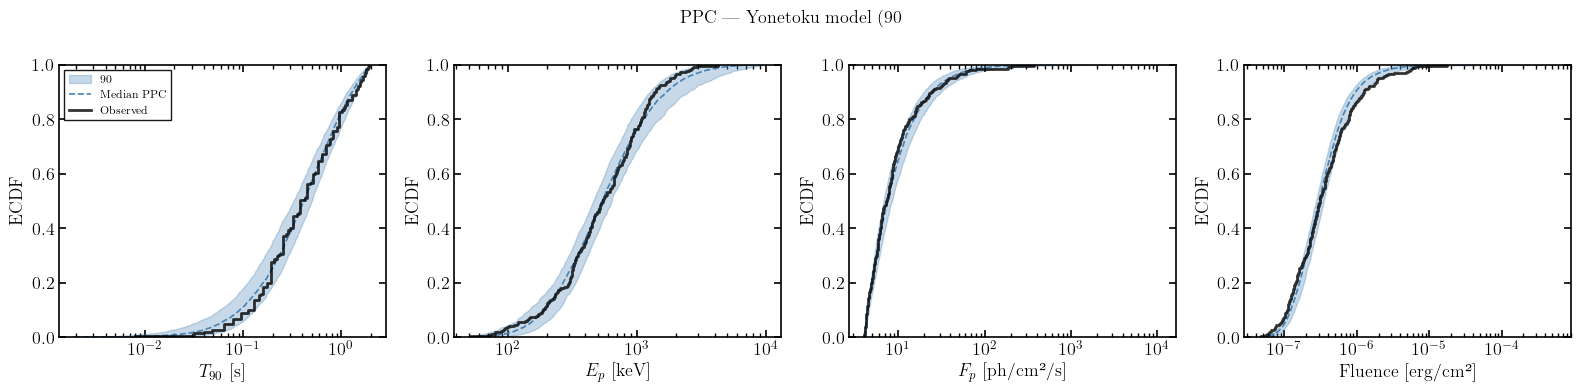

In [13]:
obs_data = {
    r"$T_{90}$ [s]"      : (sim_params.duration_data, "t90"),
    r"$E_p$ [keV]"       : (sim_params.epeak_data,    "epeak"),
    r"$F_p$ [ph/cm²/s]"  : (sim_params.pflux_data,    "pflux"),
    r"Fluence [erg/cm²]" : (sim_params.fluence_data,  "fluence"),
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, (label, (obs, key)) in zip(axes, obs_data.items()):
    # common x-grid
    all_vals = np.concatenate(
        [obs] + [pop[key] for pop in ppc_results if len(pop[key]) > 0]
    )
    x_grid = np.logspace(np.log10(all_vals.min()), np.log10(all_vals.max()), 500)

    # PPC ECDF band
    ppc_cdfs = []
    for pop in ppc_results:
        sim_vals = pop[key]
        if len(sim_vals) > 0:
            ss = np.sort(sim_vals)
            sc = np.arange(1, len(ss) + 1) / len(ss)
            ppc_cdfs.append(np.interp(x_grid, ss, sc, left=0.0, right=1.0))

    ppc_cdfs = np.array(ppc_cdfs)
    lo_band  = np.percentile(ppc_cdfs,  5, axis=0)
    hi_band  = np.percentile(ppc_cdfs, 95, axis=0)
    med_band = np.percentile(ppc_cdfs, 50, axis=0)

    ax.fill_between(x_grid, lo_band, hi_band, color="steelblue", alpha=0.3, label="90% C.I.")
    ax.plot(x_grid, med_band, color="steelblue", lw=1.2, ls="--", label="Median PPC")

    # Observed ECDF
    obs_s = np.sort(obs)
    obs_c = np.arange(1, len(obs_s) + 1) / len(obs_s)
    ax.step(obs_s, obs_c, where="post", color="k", lw=2, label="Observed", zorder=5, alpha=0.8)

    ax.set_xscale("log")
    ax.set_ylim(0, 1)
    ax.set_xlabel(label)
    ax.set_ylabel("ECDF")
    if ax == axes[0]:
        ax.legend(fontsize=8)

fig.suptitle("PPC — Yonetoku model (90% C.I. band)", fontsize=13)
fig.tight_layout()
fig.savefig(output_dir / "ppc_yonetoku.pdf", bbox_inches="tight")
plt.show()

## 11. $f_j$ and $\gamma_y$ summary

── fj posterior ────────────────────────────────────────────────────
  fj = 0.7837  +0.5666  -0.3287

── gamma_y posterior (Yonetoku slope) ──────────────────────────────
  gamma_y = 0.578  +0.570  -0.522
  (canonical Yonetoku: 0.5)

── Implied GBM rate (before detection efficiency) ──────────────────
  2565.2  +1854.7  -1075.8  sGRBs/yr
  Observed rate in catalogue : 18.58 sGRBs/yr


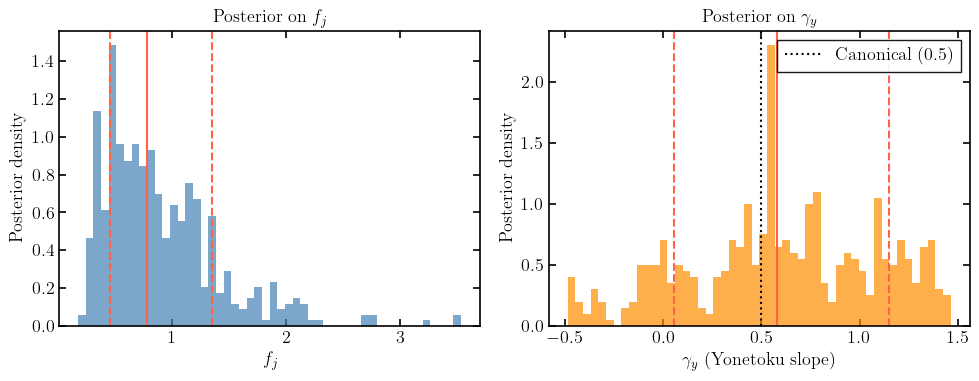

In [14]:
fj_samples      = flat_samples[:, 6]
gamma_y_samples = flat_samples[:, 7]

geo_eff      = 1 - np.cos(sim_params.theta_v_max)
n_bns_yr_val = len(sim_params.z_arr)
rate_per_yr  = n_bns_yr_val * fj_samples * geo_eff * GBM_EFF

print("── fj posterior ────────────────────────────────────────────────────")
fj_lo, fj_med, fj_hi = np.percentile(fj_samples, [16, 50, 84])
print(f"  fj = {fj_med:.4f}  +{fj_hi-fj_med:.4f}  -{fj_med-fj_lo:.4f}")

print("\n── gamma_y posterior (Yonetoku slope) ──────────────────────────────")
gy_lo, gy_med, gy_hi = np.percentile(gamma_y_samples, [16, 50, 84])
print(f"  gamma_y = {gy_med:.3f}  +{gy_hi-gy_med:.3f}  -{gy_med-gy_lo:.3f}")
print(f"  (canonical Yonetoku: 0.5)")

print("\n── Implied GBM rate (before detection efficiency) ──────────────────")
r_lo, r_med, r_hi = np.percentile(rate_per_yr, [16, 50, 84])
print(f"  {r_med:.1f}  +{r_hi-r_med:.1f}  -{r_med-r_lo:.1f}  sGRBs/yr")
print(f"  Observed rate in catalogue : {sim_params.yearly_rate:.2f} sGRBs/yr")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ax = axes[0]
ax.hist(fj_samples, bins=50, density=True, color="steelblue", alpha=0.7)
for q, ls in zip([fj_lo, fj_med, fj_hi], ["--", "-", "--"]):
    ax.axvline(q, color="tomato", ls=ls, lw=1.5)
ax.set_xlabel(r"$f_j$")
ax.set_ylabel("Posterior density")
ax.set_title(r"Posterior on $f_j$")

ax = axes[1]
ax.hist(gamma_y_samples, bins=50, density=True, color="darkorange", alpha=0.7)
for q, ls in zip([gy_lo, gy_med, gy_hi], ["--", "-", "--"]):
    ax.axvline(q, color="tomato", ls=ls, lw=1.5)
ax.axvline(0.5, color="k", ls=":", lw=1.5, label="Canonical (0.5)")
ax.set_xlabel(r"$\gamma_y$  (Yonetoku slope)")
ax.set_ylabel("Posterior density")
ax.set_title(r"Posterior on $\gamma_y$")
ax.legend()

fig.tight_layout()
fig.savefig(output_dir / "fj_gamma_posterior.pdf", bbox_inches="tight")
plt.show()

## 12. Yonetoku correlation check

Visualise the posterior predictive $E_p$–$E_{\rm iso}$ (Yonetoku) plane against the observed data.  
This is the key diagnostic for $\gamma_y$: if the model fits the correlation the PPC cloud should
bracket the observed trend.

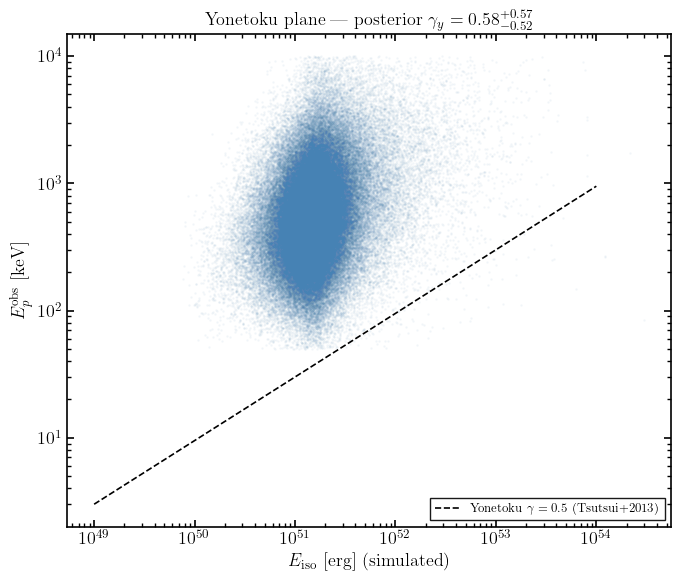

In [15]:
# ── E_p vs E_iso (Yonetoku) plane ────────────────────────────────────────────
# E_iso is stored in the PPC output as isotropic_energy_det (erg).
# E_p is the observer-frame peak energy.

fig, ax = plt.subplots(figsize=(7, 6))

for pop in ppc_results:
    ep  = pop["epeak"]
    ei  = pop["isotropic_energy_det"]
    if len(ep) > 0:
        ax.scatter(ei, ep, s=1, alpha=0.04, color="steelblue", rasterized=True)

# Observed data — E_iso not available from catalogue directly, but we can
# use pflux as a proxy for luminosity on the same plot using a second axis.
# If data_dict stores isotropic data, plot it; otherwise skip.
if "E_iso" in data_dict:
    ax.scatter(data_dict["E_iso"], sim_params.epeak_data,
               s=10, color="k", zorder=5, label="Observed")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$E_{\rm iso}$ [erg]  (simulated)")
ax.set_ylabel(r"$E_p^{\rm obs}$ [keV]")
ax.set_title(
    rf"Yonetoku plane — posterior $\gamma_y = {gy_med:.2f}_{{-{gy_med-gy_lo:.2f}}}^{{+{gy_hi-gy_med:.2f}}}$"
)

# Overlay the canonical Yonetoku power law for reference
E_iso_grid = np.logspace(49, 54, 200)
Ep_yonetoku = 95 * (E_iso_grid / 1e52)**0.5   # Tsutsui+ 2013 sGRB normalisation
ax.plot(E_iso_grid, Ep_yonetoku, "k--", lw=1.2, label=r"Yonetoku $\gamma=0.5$ (Tsutsui+2013)")
ax.legend(fontsize=9, markerscale=5)

fig.tight_layout()
fig.savefig(output_dir / "yonetoku_plane.pdf", bbox_inches="tight")
plt.show()

## 13. Model comparison: Yonetoku vs. baseline

Compare the marginal posteriors of shared parameters between this run and the baseline
CvM run (if you have run `structured_jet_run.ipynb` first and have its `backend_file`).

If `gamma_y` is consistent with 0 at the 2-σ level then the data do not require
the correlation; if it is inconsistent with 0 the Yonetoku term is preferred.

In [16]:
# ── Optional: overlay baseline posteriors ────────────────────────────────────
# Provide the path to the baseline CvM run emcee.h5 if you want to compare.
# Set baseline_h5 = None to skip.

baseline_h5 = None   # e.g. Path("../Output_files/structured_jet/fj_run_.../emcee.h5")

if baseline_h5 is not None and Path(baseline_h5).exists():
    baseline_reader = emcee.backends.HDFBackend(str(baseline_h5), read_only=True)
    try:
        tau_b   = baseline_reader.get_autocorr_time(tol=0)
        burn_b  = int(3 * np.max(tau_b))
        thin_b  = max(1, int(0.5 * np.min(tau_b)))
    except Exception:
        burn_b, thin_b = N_STEPS // 4, 1
    base_samples = baseline_reader.get_chain(discard=burn_b, thin=thin_b, flat=True)
    shared_labels = [
        r"$k_{\rm pl}$", r"$\log L_0$", r"$\mu_E$", r"$\sigma_E$",
        r"$\mu_\tau$", r"$\sigma_\tau$", r"$f_j$",
    ]
    fig, axes = plt.subplots(1, 7, figsize=(18, 4))
    for i, (ax, lbl) in enumerate(zip(axes, shared_labels)):
        ax.hist(flat_samples[:, i],  bins=40, density=True,
                color="steelblue", alpha=0.6, label="Yonetoku")
        ax.hist(base_samples[:, i],  bins=40, density=True,
                color="tomato",    alpha=0.5, label="Baseline", histtype="step", lw=2)
        ax.set_xlabel(lbl, fontsize=9)
        ax.set_yticks([])
    axes[0].set_ylabel("Density")
    axes[0].legend(fontsize=9)
    fig.suptitle("Marginal comparison: Yonetoku vs. baseline", fontsize=12)
    fig.tight_layout()
    fig.savefig(output_dir / "model_comparison.pdf", bbox_inches="tight")
    plt.show()
else:
    print("No baseline chain provided — skipping model comparison plot.")
    print("Set  baseline_h5 = <path_to_emcee.h5>  to enable this cell.")

# ── gamma_y: is the correlation needed? ──────────────────────────────────────
print(f"\ngamma_y posterior: {gy_med:.3f}  +{gy_hi-gy_med:.3f}  -{gy_med-gy_lo:.3f}")
print(f"  Lower 2-sigma    : {np.percentile(gamma_y_samples, 2.3):.3f}")
print(f"  Upper 2-sigma    : {np.percentile(gamma_y_samples, 97.7):.3f}")
if np.percentile(gamma_y_samples, 2.3) > 0:
    print("  → gamma_y > 0 at >2σ: Yonetoku correlation is required by the data.")
elif np.percentile(gamma_y_samples, 97.7) < 0:
    print("  → gamma_y < 0 at >2σ: anti-correlation favoured (unexpected).")
else:
    print("  → 0 is within the 2σ interval: baseline model is consistent.")

No baseline chain provided — skipping model comparison plot.
Set  baseline_h5 = <path_to_emcee.h5>  to enable this cell.

gamma_y posterior: 0.578  +0.570  -0.522
  Lower 2-sigma    : -0.394
  Upper 2-sigma    : 1.378
  → 0 is within the 2σ interval: baseline model is consistent.
